# Franka Push SAC+HER 正式训练 — 方案 B：Dense → Sparse

**平台：AutoDL / Linux**

**固定环境栈**
- MuJoCo 3.12.0
- Gymnasium 1.3.0
- Gymnasium-Robotics 1.4.2
- Stable-Baselines3 2.9.0
- SB3-Contrib 2.9.0
- Python 3.12.x 可用

本 notebook 参考之前的 `Franka_Push_SAC_HER_MuJoCo3_Colab_FINAL.ipynb` 和 Dense→Sparse 版本，
并针对 AutoDL 做了以下调整：

1. 仓库固定使用 `/root/panda_mujoco_gym`；
2. 顶部自动应用已经验证有效的 MuJoCo 3 joint compatibility patch；
3. **不再执行 pip 安装或 git clone**，避免破坏已经配置好的服务器环境；
4. 两个消融方案使用完全相同的 SAC+HER、网络结构、训练预算、50-step horizon 和评估指标；
5. `model.learn(..., progress_bar=False)`，避免 Jupyter/ipywidgets 进度条弹窗问题；
6. 本文件为正式训练版，固定训练 500,000 environment timesteps。

> `AdroitHand... reward functions were updated` 是 Gymnasium-Robotics 的提示，与 Franka Push 无关，可以忽略。

**训练预算：500,000 timesteps；默认 seed=42。**

## 1. 环境检查 + MuJoCo 3 joint compatibility patch

这一步不会重新安装任何包，也不会修改训练算法。  
它只是在当前 Python 进程中替换 Gymnasium-Robotics 的 joint qpos/qvel 访问函数，
解决 MuJoCo 3.x 下的 joint type 兼容问题。

In [1]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import mujoco

REPO = Path("/root/panda_mujoco_gym")
if not REPO.exists():
    raise RuntimeError(
        f"{REPO} 不存在。请先在终端 git clone "
        "https://github.com/zichunxx/panda_mujoco_gym.git /root/panda_mujoco_gym"
    )

os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

expected = {
    "mujoco": "3.12.0",
    "gymnasium": "1.3.0",
    "gymnasium_robotics": "1.4.2",
    "stable_baselines3": "2.9.0",
    "sb3_contrib": "2.9.0",
}

print("Python:", sys.version)
print("Working directory:", os.getcwd())
for name, exp in expected.items():
    m = importlib.import_module(name)
    got = getattr(m, "__version__", "unknown")
    print(f"{name}: {got} (expected {exp})")

assert int(mujoco.__version__.split(".")[0]) >= 3

from gymnasium_robotics.utils import mujoco_utils

def _joint_meta(model, name):
    jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
    if jid < 0:
        raise RuntimeError(f"Joint not found: {name}")

    jt = int(model.jnt_type[jid])
    qadr = int(model.jnt_qposadr[jid])
    dadr = int(model.jnt_dofadr[jid])

    FREE = int(mujoco.mjtJoint.mjJNT_FREE)
    BALL = int(mujoco.mjtJoint.mjJNT_BALL)
    SLIDE = int(mujoco.mjtJoint.mjJNT_SLIDE)
    HINGE = int(mujoco.mjtJoint.mjJNT_HINGE)

    if jt == FREE:
        qn, vn = 7, 6
    elif jt == BALL:
        qn, vn = 4, 3
    elif jt in (SLIDE, HINGE):
        qn, vn = 1, 1
    else:
        raise RuntimeError(f"Unsupported joint type {jt} for {name}")

    return qadr, dadr, qn, vn

def set_joint_qpos_fix(model, data, name, value):
    qadr, _, qn, _ = _joint_meta(model, name)
    value = np.asarray(value, dtype=np.float64).reshape(-1)
    if qn == 1:
        data.qpos[qadr] = float(value[0])
    else:
        if value.size != qn:
            raise ValueError(f"{name}: expected {qn} qpos values, got {value.size}")
        data.qpos[qadr:qadr + qn] = value

def get_joint_qpos_fix(model, data, name):
    qadr, _, qn, _ = _joint_meta(model, name)
    value = data.qpos[qadr:qadr + qn].copy()
    return float(value[0]) if qn == 1 else value

def set_joint_qvel_fix(model, data, name, value):
    _, dadr, _, vn = _joint_meta(model, name)
    value = np.asarray(value, dtype=np.float64).reshape(-1)
    if vn == 1:
        data.qvel[dadr] = float(value[0])
    else:
        if value.size != vn:
            raise ValueError(f"{name}: expected {vn} qvel values, got {value.size}")
        data.qvel[dadr:dadr + vn] = value

def get_joint_qvel_fix(model, data, name):
    _, dadr, _, vn = _joint_meta(model, name)
    value = data.qvel[dadr:dadr + vn].copy()
    return float(value[0]) if vn == 1 else value

mujoco_utils.set_joint_qpos = set_joint_qpos_fix
mujoco_utils.get_joint_qpos = get_joint_qpos_fix
mujoco_utils.set_joint_qvel = set_joint_qvel_fix
mujoco_utils.get_joint_qvel = get_joint_qvel_fix

print("\nMuJoCo 3 joint compatibility patch applied.")

import gymnasium as gym
import panda_mujoco_gym

print("Registered Franka envs:")
print([x for x in gym.registry.keys() if "Franka" in x])

probe = gym.make("FrankaPushSparse-v0")
obs, info = probe.reset(seed=0)
for _ in range(3):
    obs, r, terminated, truncated, info = probe.step(probe.action_space.sample())
probe.close()
print("Base Franka environment check PASSED.")

Python: 3.12.3 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:46:43) [GCC 11.2.0]
Working directory: /root/panda_mujoco_gym
mujoco: 3.12.0 (expected 3.12.0)
gymnasium: 1.3.0 (expected 1.3.0)
gymnasium_robotics: 1.4.2 (expected 1.4.2)


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


stable_baselines3: 2.9.0 (expected 2.9.0)
sb3_contrib: 2.9.0 (expected 2.9.0)

MuJoCo 3 joint compatibility patch applied.
Registered Franka envs:
['FrankaKitchen-v1', 'FrankaSlideSparse-v0', 'FrankaSlideDense-v0', 'FrankaPushSparse-v0', 'FrankaPushDense-v0', 'FrankaPickAndPlaceSparse-v0', 'FrankaPickAndPlaceDense-v0']
Base Franka environment check PASSED.


/root/miniconda3/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:226: UserWarning: WARN: Expects `terminated` signal to be a boolean, actual type: <class 'numpy.float32'>
  logger.warn(


## 2. 正式实验配置

**消融公平性约束**
- SAC + HER 完全一致；
- Actor/Critic 网络完全一致；
- 训练总步数一致；
- replay buffer、batch size、学习率等一致；
- 两个方案都使用 **固定 50 步 horizon，不因成功提前终止**；
- 统一用成功率、最终距离、最小距离等 reward-independent 指标比较。

本文件固定进行 500,000 environment timesteps 正式训练。

In [2]:
import csv
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

import panda_mujoco_gym
from panda_mujoco_gym.envs.push import FrankaPushEnv

from stable_baselines3 import SAC, HerReplayBuffer
from stable_baselines3.common.callbacks import BaseCallback, CallbackList, CheckpointCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.type_aliases import DictReplayBufferSamples
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
from tqdm import tqdm

SCHEME = "dense2sparse"
RUN_MODE = "full"
SEED = 42

# Reward
REWARD_A = 1.0
REWARD_K = 5.0
DENSE_K = 5.0
D_SUCCESS = 0.05
DENSE_FRACTION = 0.40

# Environment / HER
MAX_EPISODE_STEPS = 50
TERMINATE_ON_SUCCESS = False
N_SAMPLED_GOAL = 4
GOAL_SELECTION_STRATEGY = "future"

# SAC — 两个方案必须保持完全相同
N_ENVS = 4
BATCH_SIZE = 512
TRAIN_FREQ = 4
BUFFER_SIZE = 1_000_000
LEARNING_STARTS = 5_000
LEARNING_RATE = 3e-4
GAMMA = 0.95
TAU = 0.005
NET_ARCH = [256, 256]

TOTAL_TIMESTEPS = 500_000
EVAL_FREQ = 20_000
CHECKPOINT_FREQ = 50_000
N_EVAL_EPISODES = 20

SWITCH_STEP = int(TOTAL_TIMESTEPS * DENSE_FRACTION)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

data_root = Path("/root/autodl-tmp") if Path("/root/autodl-tmp").exists() else Path("/root")
stamp = time.strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"SAC_HER_{SCHEME}_{RUN_MODE}_seed{SEED}_{stamp}"
ROOT = data_root / "franka_ablation" / SCHEME / RUN_NAME
TB_DIR = ROOT / "tensorboard"
MODEL_DIR = ROOT / "models"
EVAL_DIR = ROOT / "eval"
FIG_DIR = ROOT / "figures"

for p in [TB_DIR, MODEL_DIR, EVAL_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")

config = dict(
    scheme=SCHEME,
    run_mode=RUN_MODE,
    seed=SEED,
    total_timesteps=TOTAL_TIMESTEPS,
    max_episode_steps=MAX_EPISODE_STEPS,
    terminate_on_success=TERMINATE_ON_SUCCESS,
    n_envs=N_ENVS,
    batch_size=BATCH_SIZE,
    train_freq=TRAIN_FREQ,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    tau=TAU,
    net_arch=NET_ARCH,
    n_sampled_goal=N_SAMPLED_GOAL,
    goal_selection_strategy=GOAL_SELECTION_STRATEGY,
    dense_fraction=DENSE_FRACTION,
    switch_step=SWITCH_STEP,
    device=DEVICE,
)
(ROOT / "config.json").write_text(json.dumps(config, indent=2))

print("Scheme:", SCHEME)
print("Mode:", RUN_MODE)
print("Run:", RUN_NAME)
print("Output:", ROOT)
print("Device:", DEVICE)
print("Total timesteps:", TOTAL_TIMESTEPS)
if SCHEME == "dense2sparse":
    print("Dense -> Sparse switch:", SWITCH_STEP)

Scheme: dense2sparse
Mode: full
Run: SAC_HER_dense2sparse_full_seed42_20260901_143014
Output: /root/autodl-tmp/franka_ablation/dense2sparse/SAC_HER_dense2sparse_full_seed42_20260901_143014
Device: cuda
Total timesteps: 500000
Dense -> Sparse switch: 200000


## 3. 方案 B 环境：Dense → Sparse

前期：
\[
r_{\mathrm{dense}}=-	anh(kd)
\]

后期：
\[
r_{\mathrm{sparse}}=
egin{cases}
0,&d\le d_s\
-1,&d>d_s
\end{cases}
\]

切换发生在**训练时间轴**，不是按当前距离切换。

In [3]:
class FrankaPushAblationEnv(FrankaPushEnv):
    def __init__(
        self,
        dense_k=5.0,
        d_success=0.05,
        reward_mode="dense",
        max_episode_steps=50,
        terminate_on_success=False,
        render_mode=None,
    ):
        self.dense_k = float(dense_k)
        self.d_success = float(d_success)
        self.reward_mode = str(reward_mode)
        self.custom_max_episode_steps = int(max_episode_steps)
        self.terminate_on_success = bool(terminate_on_success)
        self._custom_elapsed_steps = 0

        super().__init__(reward_type="dense", render_mode=render_mode)
        self.distance_threshold = self.d_success

    def set_reward_mode(self, mode):
        mode = str(mode).lower()
        if mode not in {"dense", "sparse"}:
            raise ValueError(mode)
        self.reward_mode = mode
        return mode

    def get_reward_mode(self):
        return self.reward_mode

    def compute_reward(self, achieved_goal, desired_goal, info):
        ag = np.asarray(achieved_goal, dtype=np.float32)
        dg = np.asarray(desired_goal, dtype=np.float32)
        d = np.linalg.norm(ag - dg, axis=-1)

        if self.reward_mode == "dense":
            r = -np.tanh(self.dense_k * d)
        else:
            r = np.where(d <= self.d_success, 0.0, -1.0)

        r = np.asarray(r, dtype=np.float32)
        return float(r) if r.ndim == 0 else r

    def reset(self, *, seed=None, options=None):
        self._custom_elapsed_steps = 0
        return super().reset(seed=seed, options=options)

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        self._custom_elapsed_steps += 1

        distance = float(np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"]))
        success = bool(distance <= self.d_success)

        info = dict(info)
        info["is_success"] = success
        info["distance_to_goal"] = distance
        info["reward_mode"] = self.reward_mode

        terminated = success if self.terminate_on_success else False
        truncated = bool(self._custom_elapsed_steps >= self.custom_max_episode_steps)

        return obs, float(reward), bool(terminated), bool(truncated), info

class GoalMonitor(Monitor):
    def compute_reward(self, achieved_goal, desired_goal, info):
        return self.env.compute_reward(achieved_goal, desired_goal, info)

    def set_reward_mode(self, mode):
        return self.env.set_reward_mode(mode)

    def get_reward_mode(self):
        return self.env.get_reward_mode()

## 4. Phase-aware HER Replay Buffer

Dense→Sparse 切换后，旧 replay 中的真实 transition 不能继续保留旧 dense reward。
因此采样时按**当前 reward mode**重新计算真实样本奖励；HER 虚拟样本仍由 HER 正常重算。

In [4]:
class PhaseAwareHerReplayBuffer(HerReplayBuffer):
    def _get_real_samples(self, batch_indices, env_indices, env=None):
        obs_raw = {
            k: v[batch_indices, env_indices, :]
            for k, v in self.observations.items()
        }
        next_raw = {
            k: v[batch_indices, env_indices, :]
            for k, v in self.next_observations.items()
        }

        infos = [{} for _ in range(len(batch_indices))]
        if self.env is None:
            raise RuntimeError("HER buffer requires VecEnv")

        rewards = self.env.env_method(
            "compute_reward",
            next_raw["achieved_goal"],
            obs_raw["desired_goal"],
            infos,
            indices=[0],
        )[0]
        rewards = np.asarray(rewards, dtype=np.float32)

        obs = self._normalize_obs(obs_raw, env)
        nxt = self._normalize_obs(next_raw, env)
        dones = (
            self.dones[batch_indices, env_indices]
            * (1 - self.timeouts[batch_indices, env_indices])
        )
        rewards = self._normalize_reward(rewards.reshape(-1, 1), env)

        return DictReplayBufferSamples(
            observations={k: self.to_torch(v) for k, v in obs.items()},
            actions=self.to_torch(self.actions[batch_indices, env_indices]),
            next_observations={k: self.to_torch(v) for k, v in nxt.items()},
            dones=self.to_torch(dones).reshape(-1, 1),
            rewards=self.to_torch(rewards),
        )

## 5. 自定义环境 smoke test

In [5]:
test_env = FrankaPushAblationEnv(
    dense_k=DENSE_K, d_success=D_SUCCESS, reward_mode="dense",
    max_episode_steps=MAX_EPISODE_STEPS,
    terminate_on_success=TERMINATE_ON_SUCCESS,
)

obs, info = test_env.reset(seed=SEED)
print("Observation keys:", obs.keys())
print("Action space:", test_env.action_space)
print("Initial reward:", test_env.compute_reward(
    obs["achieved_goal"], obs["desired_goal"], {}
))

ag = np.stack([obs["achieved_goal"]] * 2)
dg = np.stack([obs["desired_goal"]] * 2)
print("Vectorized reward:", test_env.compute_reward(ag, dg, [{}, {}]))


test_env.set_reward_mode("sparse")
print("Sparse reward:", test_env.compute_reward(obs["achieved_goal"], obs["desired_goal"], {}))
test_env.set_reward_mode("dense")


for i in range(5):
    obs, r, term, trunc, info = test_env.step(test_env.action_space.sample())
    print(
        i + 1,
        "r=", round(float(r), 4),
        "d=", round(float(info["distance_to_goal"]), 4),
        "success=", info["is_success"],
        "term=", term,
        "trunc=", trunc,
    )
    if term or trunc:
        obs, info = test_env.reset()

test_env.close()
print("Custom environment smoke test PASSED.")

Observation keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])
Action space: Box(-1.0, 1.0, (3,), float32)
Initial reward: -0.48512160778045654
Vectorized reward: [-0.4851216 -0.4851216]
Sparse reward: -1.0
1 r= -0.4851 d= 0.1059 success= False term= False trunc= False
2 r= -0.4851 d= 0.1059 success= False term= False trunc= False
3 r= -0.4851 d= 0.1059 success= False term= False trunc= False
4 r= -0.4851 d= 0.1059 success= False term= False trunc= False
5 r= -0.4851 d= 0.1059 success= False term= False trunc= False
Custom environment smoke test PASSED.


## 6. 并行训练环境

In [6]:
def make_worker(rank):
    def _init():
        os.environ["OMP_NUM_THREADS"] = "1"
        os.environ["MKL_NUM_THREADS"] = "1"

        env = FrankaPushAblationEnv(
            dense_k=DENSE_K, d_success=D_SUCCESS, reward_mode="dense",
            max_episode_steps=MAX_EPISODE_STEPS,
            terminate_on_success=TERMINATE_ON_SUCCESS,
        )
        env.reset(seed=SEED + rank)
        return GoalMonitor(env)
    return _init

for name in ["train_env", "eval_env"]:
    old = globals().get(name)
    if old is not None:
        try:
            old.close()
        except Exception:
            pass

try:
    train_env = SubprocVecEnv(
        [make_worker(i) for i in range(N_ENVS)],
        start_method="fork",
    )
    backend = "SubprocVecEnv"
except Exception as exc:
    print("SubprocVecEnv failed; fallback to DummyVecEnv:", type(exc).__name__, exc)
    train_env = DummyVecEnv([make_worker(i) for i in range(N_ENVS)])
    backend = "DummyVecEnv"

eval_env = FrankaPushAblationEnv(
    dense_k=DENSE_K, d_success=D_SUCCESS, reward_mode="dense",
    max_episode_steps=MAX_EPISODE_STEPS,
    terminate_on_success=TERMINATE_ON_SUCCESS,
)
eval_env.reset(seed=SEED + 10_000)

print("Backend:", backend)
print("n_envs:", train_env.num_envs)

Backend: SubprocVecEnv
n_envs: 4


## 7. 统一评估回调

两个方案的 raw reward 尺度不同，因此**不要用 raw return 直接判断谁更好**。
统一记录：
- success rate
- mean final distance
- mean minimum distance
- fixed tanh oracle return
- fixed sparse oracle return

In [7]:
class TextProgressCallback(BaseCallback):
    def __init__(self, total):
        super().__init__(0)
        self.total = int(total)
        self.pbar = None
        self.last = 0

    def _on_training_start(self):
        self.last = int(self.num_timesteps)
        self.pbar = tqdm(
            total=self.total,
            initial=min(self.last, self.total),
            desc="Training",
            unit="step",
            dynamic_ncols=True,
        )

    def _on_step(self):
        cur = int(self.num_timesteps)
        delta = max(cur - self.last, 0)
        if self.pbar is not None and delta:
            self.pbar.update(delta)
        self.last = cur
        return True

    def _on_training_end(self):
        if self.pbar is not None:
            self.pbar.close()
            self.pbar = None


class GoalEvalCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq, n_eval_episodes, csv_path, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.csv_path = Path(csv_path)
        self.last_eval_step = 0

    def _on_training_start(self):
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        if not self.csv_path.exists():
            pd.DataFrame(columns=[
                "timesteps",
                "phase",
                "success_rate",
                "native_return",
                "oracle_tanh_return",
                "oracle_sparse_return",
                "mean_final_distance",
                "mean_min_distance",
            ]).to_csv(self.csv_path, index=False)

    def _on_step(self):
        if self.num_timesteps - self.last_eval_step < self.eval_freq:
            return True

        self.last_eval_step = int(self.num_timesteps)

        native_returns = []
        tanh_returns = []
        sparse_returns = []
        successes = []
        final_distances = []
        min_distances = []

        for ep in range(self.n_eval_episodes):
            obs, info = self.eval_env.reset(seed=10_000 + ep)
            native_ret = 0.0
            tanh_ret = 0.0
            sparse_ret = 0.0
            ever_success = False
            final_d = np.nan
            min_d = np.inf

            for _ in range(MAX_EPISODE_STEPS):
                action, _ = self.model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = self.eval_env.step(action)

                d = float(info["distance_to_goal"])
                native_ret += float(reward)
                tanh_ret += float(REWARD_A * (1.0 - np.tanh(REWARD_K * d)))
                sparse_ret += 0.0 if d <= D_SUCCESS else -1.0

                ever_success |= bool(info["is_success"])
                final_d = d
                min_d = min(min_d, d)

                if terminated or truncated:
                    break

            native_returns.append(native_ret)
            tanh_returns.append(tanh_ret)
            sparse_returns.append(sparse_ret)
            successes.append(float(ever_success))
            final_distances.append(final_d)
            min_distances.append(min_d)

        if SCHEME == "dense2sparse":
            phase = self.eval_env.get_reward_mode()
        else:
            phase = "tanh"

        row = dict(
            timesteps=int(self.num_timesteps),
            phase=phase,
            success_rate=float(np.mean(successes)),
            native_return=float(np.mean(native_returns)),
            oracle_tanh_return=float(np.mean(tanh_returns)),
            oracle_sparse_return=float(np.mean(sparse_returns)),
            mean_final_distance=float(np.nanmean(final_distances)),
            mean_min_distance=float(np.nanmean(min_distances)),
        )

        pd.DataFrame([row]).to_csv(
            self.csv_path,
            mode="a",
            header=False,
            index=False,
        )

        self.logger.record("eval/success_rate", row["success_rate"])
        self.logger.record("eval/oracle_tanh_return", row["oracle_tanh_return"])
        self.logger.record("eval/oracle_sparse_return", row["oracle_sparse_return"])
        self.logger.record("eval/final_distance", row["mean_final_distance"])
        self.logger.record("eval/min_distance", row["mean_min_distance"])

        print(
            f"\n[Eval @ {self.num_timesteps:,}] "
            f"phase={phase} "
            f"success={row['success_rate']:.3f} "
            f"final_d={row['mean_final_distance']:.4f} m "
            f"min_d={row['mean_min_distance']:.4f} m"
        )
        return True



class Dense2SparseSwitchCallback(BaseCallback):
    def __init__(self, switch_step, eval_env=None, verbose=1):
        super().__init__(verbose)
        self.switch_step = int(switch_step)
        self.eval_env = eval_env
        self.switched = False

    def _on_training_start(self):
        self.training_env.env_method("set_reward_mode", "dense")
        if self.eval_env is not None:
            self.eval_env.set_reward_mode("dense")

    def _on_step(self):
        if (not self.switched) and self.num_timesteps >= self.switch_step:
            self.training_env.env_method("set_reward_mode", "sparse")
            if self.eval_env is not None:
                self.eval_env.set_reward_mode("sparse")
            self.switched = True
            print("\n" + "=" * 70)
            print(f"Dense2Sparse SWITCH @ {self.num_timesteps:,}: dense -> sparse")
            print("=" * 70)
        return True

## 8. 创建 SAC + HER 模型

In [8]:
replay_buffer_class = PhaseAwareHerReplayBuffer
replay_buffer_kwargs = dict(
    n_sampled_goal=N_SAMPLED_GOAL,
    goal_selection_strategy=GOAL_SELECTION_STRATEGY,
    copy_info_dict=False,
)


model = SAC(
    policy="MultiInputPolicy",
    env=train_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    tau=TAU,
    train_freq=(TRAIN_FREQ, "step"),
    gradient_steps=-1,
    ent_coef="auto",
    policy_kwargs=dict(net_arch=NET_ARCH),
    replay_buffer_class=replay_buffer_class,
    replay_buffer_kwargs=replay_buffer_kwargs,
    tensorboard_log=str(TB_DIR),
    device=DEVICE,
    verbose=1,
    seed=SEED,
)

print("Model device:", model.device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Actor device:", next(model.actor.parameters()).device)
    print("CUDA allocated:", round(torch.cuda.memory_allocated() / 1024**3, 3), "GB")

Using cuda device
Model device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
Actor device: cuda:0
CUDA allocated: 0.001 GB


## 9. 开始训练

**正式训练：500,000 environment timesteps。**

In [ ]:
eval_cb = GoalEvalCallback(
    eval_env=eval_env,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    csv_path=EVAL_DIR / f"{RUN_NAME}_eval.csv",
    verbose=1,
)

progress_cb = TextProgressCallback(TOTAL_TIMESTEPS)

checkpoint_cb = CheckpointCallback(
    save_freq=max(CHECKPOINT_FREQ // N_ENVS, 1),
    save_path=str(MODEL_DIR),
    name_prefix=RUN_NAME,
    save_replay_buffer=False,
    save_vecnormalize=False,
)


switch_cb = Dense2SparseSwitchCallback(
    SWITCH_STEP,
    eval_env=eval_env,
    verbose=1,
)
callbacks_list = [switch_cb, eval_cb, progress_cb, checkpoint_cb]


callbacks = CallbackList(callbacks_list)

print("Total timesteps:", TOTAL_TIMESTEPS)
print("n_envs:", N_ENVS)
print("device:", model.device)
if SCHEME == "dense2sparse":
    print("Switch step:", SWITCH_STEP)

t0 = time.time()

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callbacks,
    tb_log_name=RUN_NAME,
    reset_num_timesteps=True,
    progress_bar=False,
)

elapsed = time.time() - t0

FINAL_MODEL_PATH = MODEL_DIR / f"{RUN_NAME}_final"
model.save(str(FINAL_MODEL_PATH))

print("Elapsed:", round(elapsed / 60, 2), "min")
print("FPS:", round(TOTAL_TIMESTEPS / max(elapsed, 1e-9), 2))
print("Saved:", str(FINAL_MODEL_PATH) + ".zip")

Total timesteps: 500000
n_envs: 4
device: cuda
Switch step: 200000
Logging to /root/autodl-tmp/franka_ablation/dense2sparse/SAC_HER_dense2sparse_full_seed42_20260901_143014/tensorboard/SAC_HER_dense2sparse_full_seed42_20260901_143014_1


Training:   0%|          | 196/500000 [00:01<46:32, 179.01step/s]  

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -29.8    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 161      |
|    time_elapsed    | 1        |
|    total_timesteps | 200      |
---------------------------------


Training:   0%|          | 388/500000 [00:02<41:53, 198.73step/s]

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -30.3    |
|    success_rate    | 0.125    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 179      |
|    time_elapsed    | 2        |
|    total_timesteps | 400      |
---------------------------------


...

Training:  44%|████▍     | 221400/500000 [2:43:56<2:46:01, 27.97step/s]

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -13.3    |
|    success_rate    | 0.81     |
| time/              |          |
|    episodes        | 4428     |
|    fps             | 22       |
|    time_elapsed    | 9836     |
|    total_timesteps | 221400   |
| train/             |          |
|    actor_loss      | 1.53     |
|    critic_loss     | 0.48     |
|    ent_coef        | 0.00889  |
|    ent_coef_loss   | 0.253    |
|    learning_rate   | 0.0003   |
|    n_updates       | 216400   |
---------------------------------


Training:  44%|████▍     | 221600/500000 [2:44:05<2:31:39, 30.59step/s]

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -13.1    |
|    success_rate    | 0.81     |
| time/              |          |
|    episodes        | 4432     |
|    fps             | 22       |
|    time_elapsed    | 9845     |
|    total_timesteps | 221600   |
| train/             |          |
|    actor_loss      | 1.37     |
|    critic_loss     | 0.423    |
|    ent_coef        | 0.00878  |
|    ent_coef_loss   | 0.658    |
|    learning_rate   | 0.0003   |
|    n_updates       | 216592   |
---------------------------------


Training:  44%|████▍     | 221772/500000 [2:44:15<3:19:58, 23.19step/s]

## 10. 训练曲线

,timesteps,phase,success_rate,native_return,oracle_tanh_return,oracle_sparse_return,mean_final_distance,mean_min_distance
20,420000,sparse,1.0,-5.95,41.679811,-5.95,0.021001,0.020549
21,440000,sparse,0.9,-9.00,42.138982,-9.00,0.022645,0.021352
22,460000,sparse,1.0,-6.80,41.940825,-6.80,0.023454,0.017673
23,480000,sparse,1.0,-4.95,42.908561,-4.95,0.018254,0.018071
24,500000,sparse,1.0,-6.00,43.039960,-6.00,0.015809,0.014892


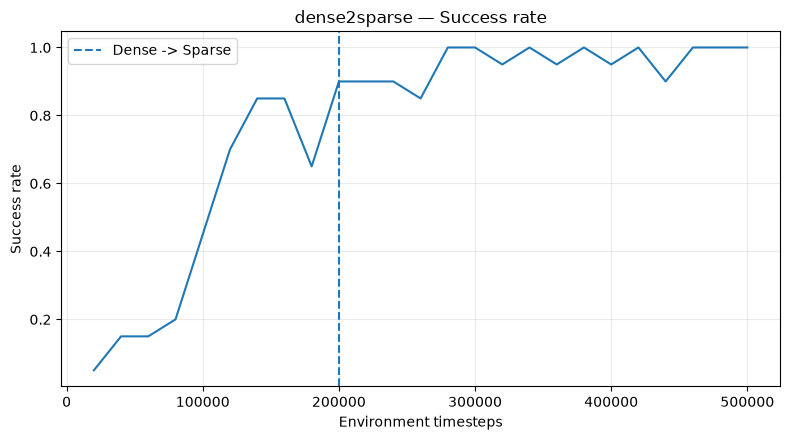

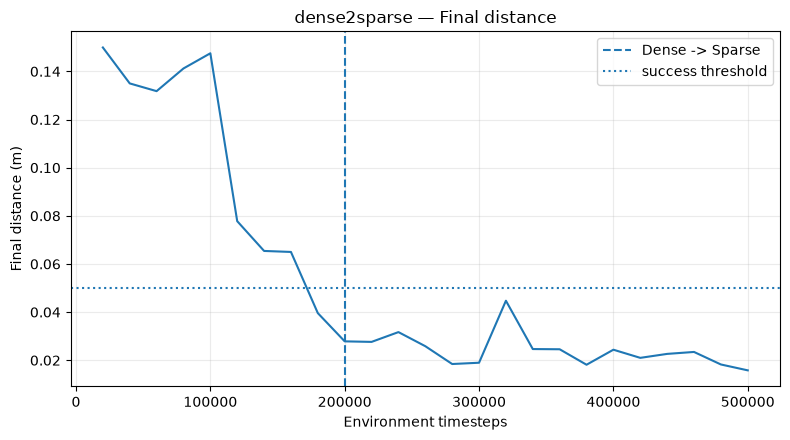

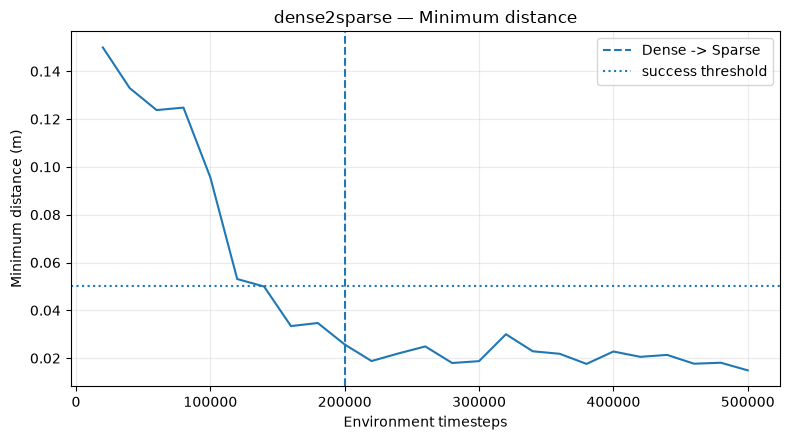

In [10]:
eval_csv = EVAL_DIR / f"{RUN_NAME}_eval.csv"
df = pd.read_csv(eval_csv)
display(df.tail())

plt.figure(figsize=(8, 4.5))
plt.plot(df["timesteps"], df["success_rate"])

plt.axvline(SWITCH_STEP, linestyle="--", label="Dense -> Sparse")

plt.xlabel("Environment timesteps")
plt.ylabel("Success rate")
plt.title(f"{SCHEME} — Success rate")
plt.grid(alpha=0.25)
plt.legend() if SCHEME == "dense2sparse" else None
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(df["timesteps"], df["mean_final_distance"])

plt.axvline(SWITCH_STEP, linestyle="--", label="Dense -> Sparse")

plt.axhline(D_SUCCESS, linestyle=":", label="success threshold")
plt.xlabel("Environment timesteps")
plt.ylabel("Final distance (m)")
plt.title(f"{SCHEME} — Final distance")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(df["timesteps"], df["mean_min_distance"])

plt.axvline(SWITCH_STEP, linestyle="--", label="Dense -> Sparse")

plt.axhline(D_SUCCESS, linestyle=":", label="success threshold")
plt.xlabel("Environment timesteps")
plt.ylabel("Minimum distance (m)")
plt.title(f"{SCHEME} — Minimum distance")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 11. 最终确定性评估

当前文件默认使用 `SEED=42`。正式消融建议后续分别改为 43、44 再各跑一次。
跨方案比较重点看：
- final success rate
- mean final distance
- mean minimum distance

不要直接比较两种奖励的 raw return。

In [11]:
eval_env.set_reward_mode("sparse")


N_FINAL_EVAL = 100
results = []

for ep in range(N_FINAL_EVAL):
    obs, info = eval_env.reset(seed=SEED + 20_000 + ep)
    ever_success = False
    min_distance = np.inf
    final_distance = np.nan
    native_return = 0.0

    for t in range(MAX_EPISODE_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)

        native_return += float(reward)
        final_distance = float(info["distance_to_goal"])
        min_distance = min(min_distance, final_distance)
        ever_success |= bool(info["is_success"])

        if terminated or truncated:
            break

    results.append({
        "episode": ep,
        "success": float(ever_success),
        "final_distance": final_distance,
        "min_distance": min_distance,
        "episode_length": t + 1,
        "native_return": native_return,
    })

final_eval = pd.DataFrame(results)
final_eval.to_csv(
    EVAL_DIR / f"{RUN_NAME}_final_eval.csv",
    index=False,
)

print("Final success rate:", final_eval["success"].mean())
print("Mean final distance:", final_eval["final_distance"].mean(), "m")
print("Mean minimum distance:", final_eval["min_distance"].mean(), "m")
print("Mean episode length:", final_eval["episode_length"].mean())

display(final_eval.describe())

Final success rate: 1.0
Mean final distance: 0.018404880485172345 m
Mean minimum distance: 0.017849137632920804 m
Mean episode length: 50.0


,episode,success,final_distance,min_distance,episode_length,native_return
count,100.000000,100.0,100.000000,100.000000,100.0,100.000000
mean,49.500000,1.0,0.018405,0.017849,50.0,-4.840000
std,29.011492,0.0,0.008063,0.008124,0.0,3.416301
min,0.000000,1.0,0.002780,0.002594,50.0,-25.000000
25%,24.750000,1.0,0.012620,0.012034,50.0,-6.000000
50%,49.500000,1.0,0.018882,0.018063,50.0,-4.000000
75%,74.250000,1.0,0.022886,0.022675,50.0,-4.000000
max,99.000000,1.0,0.043445,0.043445,50.0,0.000000


## 12. TensorBoard（可选）

在 AutoDL 的 Jupyter 中可以运行：

```python
%load_ext tensorboard
%tensorboard --logdir /root/autodl-tmp/franka_ablation
```

如果平台前端对 TensorBoard/ipywidgets 支持不好，不影响训练；直接使用 CSV 和上面的 matplotlib 曲线即可。